In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [6]:
df = pd.read_csv("C:\\Users\\amees\\Downloads\\creditcard.csv")

In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
0

Duplicate rows: 1081

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


Clean Data

In [8]:

df = df.drop_duplicates().copy()
df["Time_Hours"] = df["Time"] / 3600
df["Hour"] = (df["Time"] // 3600).astype(int) % 24
df["Amount_Log"] = np.log1p(df["Amount"])

df["Transaction_Type"] = df["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

print("\nClass distribution:")
print(df["Transaction_Type"].value_counts())


Class distribution:
Transaction_Type
Legitimate    283253
Fraud            473
Name: count, dtype: int64


KPI'S

In [9]:
total_transactions = len(df)
total_amount = df["Amount"].sum()
avg_transaction = df["Amount"].mean()
fraud_transactions = (df["Class"] == 1).sum()
fraud_amount = df.loc[df["Class"] == 1, "Amount"].sum()
fraud_rate = fraud_transactions / total_transactions * 100
fraud_amount_share = fraud_amount / total_amount * 100

print("\n========== KEY KPIs ==========")
print(f"Total Transactions      : {total_transactions:,}")
print(f"Total Transaction Value : ${total_amount:,.2f}")
print(f"Average Transaction     : ${avg_transaction:,.2f}")
print(f"Fraud Transactions      : {fraud_transactions:,}")
print(f"Fraud Rate              : {fraud_rate:.3f}%")
print(f"Fraud Transaction Value : ${fraud_amount:,.2f}")
print(f"Fraud Amount Share      : {fraud_amount_share:.3f}%")


========== KEY KPIs ==========
Total Transactions      : 283,726
Total Transaction Value : $25,102,001.68
Average Transaction     : $88.47
Fraud Transactions      : 473
Fraud Rate              : 0.167%
Fraud Transaction Value : $58,591.39
Fraud Amount Share      : 0.233%


Transaction amount by type

In [10]:
amount_by_type = (
    df.groupby("Transaction_Type")["Amount"]
      .agg(["count", "sum", "mean", "median", "max"])
      .sort_values("sum", ascending=False)
)

print("\n========== AMOUNT BY TRANSACTION TYPE ==========")
print(amount_by_type)


========== AMOUNT BY TRANSACTION TYPE ==========
                   count          sum        mean  median       max
Transaction_Type                                                   
Legitimate        283253  25043410.29   88.413575   22.00  25691.16
Fraud                473     58591.39  123.871860    9.82   2125.87


Time Trend


========== HOURLY SUMMARY ==========
      Transactions  Total_Amount  Average_Amount  Fraud_Count  Fraud_Rate_%
Hour                                                                       
0             7647     463346.88       60.591981            6      0.078462
1             4208     264126.04       62.767595           10      0.237643
2             3308     232905.95       70.406877           48      1.451028
3             3487     180492.68       51.761594           17      0.487525
4             2204     170053.44       77.156733           23      1.043557
5             2988     151498.21       50.702212           11      0.368139
6             4082     266091.36       65.186516            9      0.220480
7             7233     491013.04       67.885115           23      0.317987
8            10232     909560.54       88.893720            9      0.087959
9            15767    1622964.43      102.934257           16      0.101478
10           16548    1814463.75      109.648522  

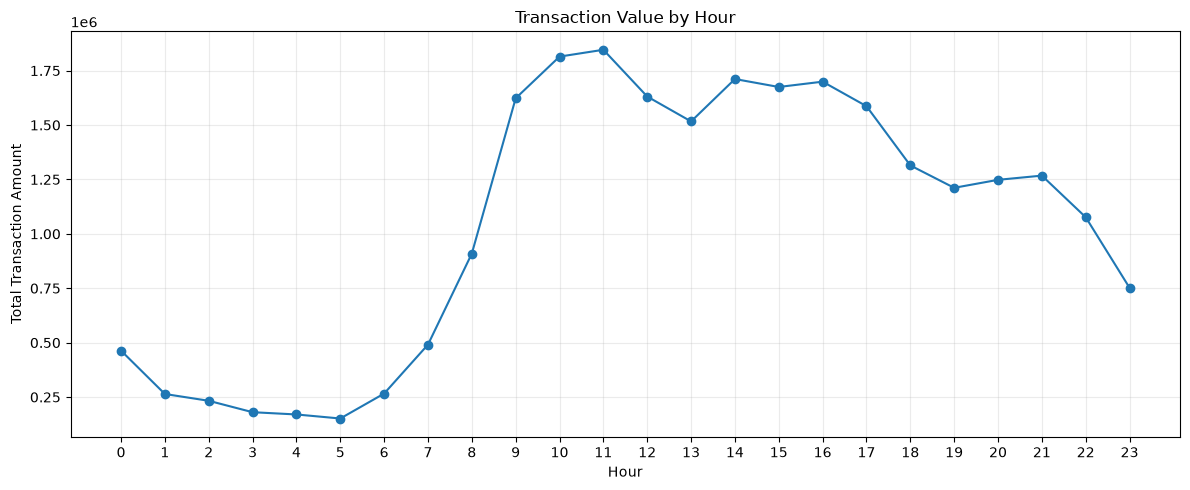

In [11]:
time_summary = (
    df.groupby("Hour")
      .agg(
          Transactions=("Amount", "size"),
          Total_Amount=("Amount", "sum"),
          Average_Amount=("Amount", "mean"),
          Fraud_Count=("Class", "sum")
      )
)

time_summary["Fraud_Rate_%"] = (
    time_summary["Fraud_Count"] / time_summary["Transactions"] * 100
)

print("\n========== HOURLY SUMMARY ==========")
print(time_summary)

plt.figure(figsize=(12, 5))
plt.plot(time_summary.index, time_summary["Total_Amount"], marker="o")
plt.title("Transaction Value by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Transaction Amount")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Fraud Trend by Hour

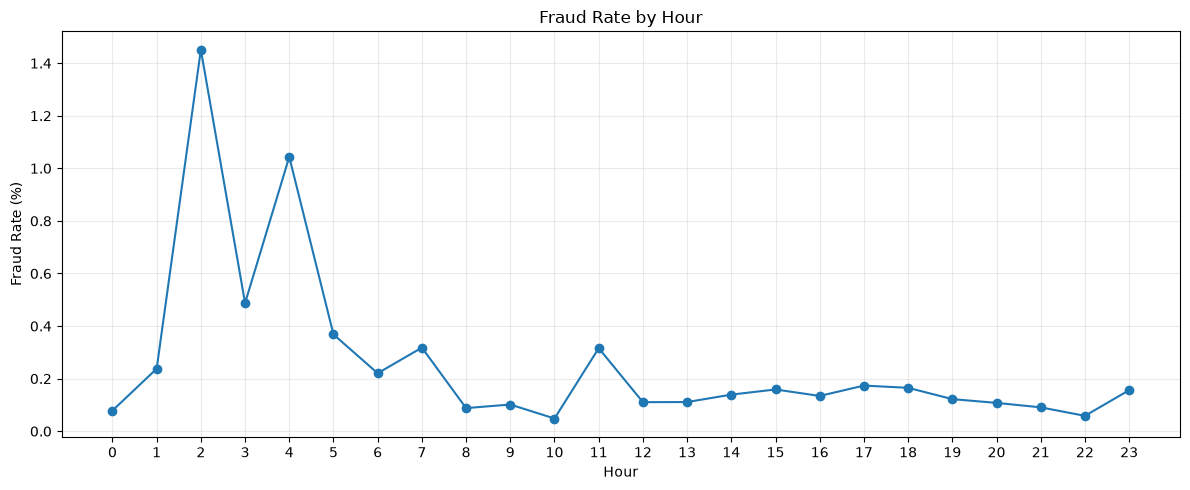

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(time_summary.index, time_summary["Fraud_Rate_%"], marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Transaction amount distribution

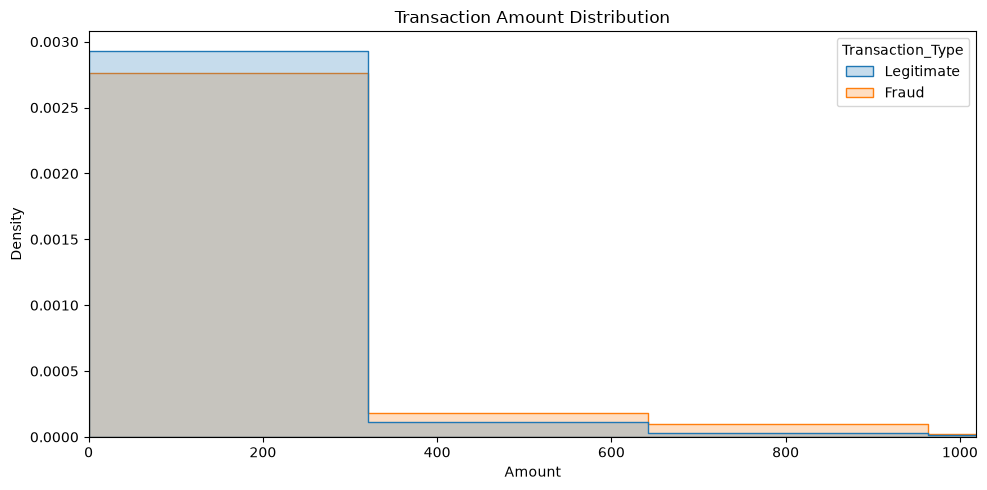

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Amount",
    hue="Transaction_Type",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)
plt.xlim(0, df["Amount"].quantile(0.99))
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.tight_layout()
plt.show()


Legitimate vs fraud amounts

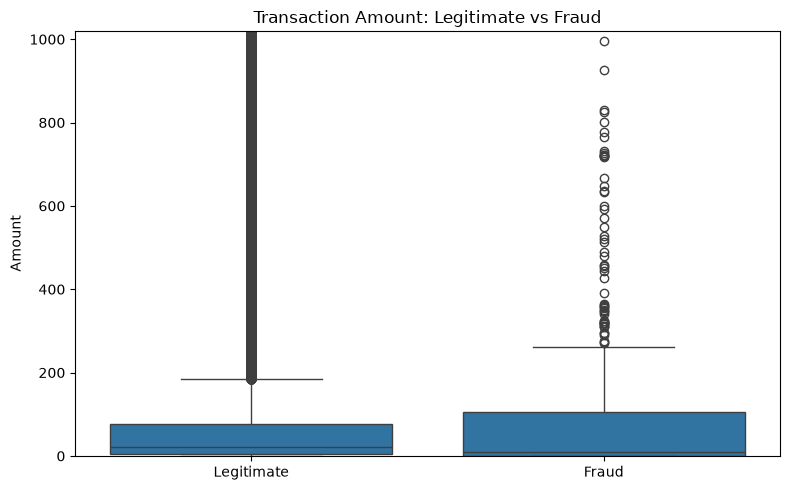

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Transaction_Type", y="Amount")
plt.ylim(0, df["Amount"].quantile(0.99))
plt.title("Transaction Amount: Legitimate vs Fraud")
plt.xlabel("")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

Top 20 highest-value transactions

In [15]:
top_20 = df.nlargest(20, "Amount")[
    ["Time", "Amount", "Transaction_Type"]
]

print("\n========== TOP 20 TRANSACTIONS ==========")
print(top_20.to_string(index=False))


========== TOP 20 TRANSACTIONS ==========
    Time   Amount Transaction_Type
166198.0 25691.16       Legitimate
 48401.0 19656.53       Legitimate
 95286.0 18910.00       Legitimate
 42951.0 12910.93       Legitimate
 46253.0 11898.09       Legitimate
119713.0 11789.84       Legitimate
172273.0 10199.44       Legitimate
145283.0 10000.00       Legitimate
 55709.0  8790.26       Legitimate
152763.0  8787.00       Legitimate
144755.0  8360.00       Legitimate
145381.0  8182.70       Legitimate
 30537.0  7879.42       Legitimate
150726.0  7862.39       Legitimate
128027.0  7766.60       Legitimate
  1264.0  7712.43       Legitimate
 47807.0  7636.30       Legitimate
133971.0  7583.32       Legitimate
141546.0  7541.70       Legitimate
 32605.0  7429.15       Legitimate


Highest-value fraud transactions

In [16]:
top_fraud = (
    df[df["Class"] == 1]
    .nlargest(20, "Amount")[
        ["Time", "Amount", "Transaction_Type"]
    ]
)

print("\n========== TOP 20 FRAUD TRANSACTIONS BY AMOUNT ==========")
print(top_fraud.to_string(index=False))


========== TOP 20 FRAUD TRANSACTIONS BY AMOUNT ==========
    Time  Amount Transaction_Type
122608.0 2125.87            Fraud
  9064.0 1809.68            Fraud
154278.0 1504.93            Fraud
 62467.0 1402.16            Fraud
 59011.0 1389.56            Fraud
 65385.0 1354.25            Fraud
133184.0 1335.00            Fraud
 18088.0 1218.89            Fraud
154309.0 1096.99            Fraud
147501.0  996.27            Fraud
134769.0  925.31            Fraud
 87883.0  829.41            Fraud
 70536.0  824.83            Fraud
 41743.0  802.52            Fraud
 39729.0  776.83            Fraud
 17838.0  766.36            Fraud
 28242.0  730.86            Fraud
138942.0  727.91            Fraud
131024.0  723.21            Fraud
139951.0  723.21            Fraud


Fraud by amount Brand


========== AMOUNT BAND ANALYSIS ==========
             Transactions  Fraud_Count  Total_Amount  Fraud_Rate_%
Amount_Band                                                       
0-10                99821          238     388145.58      0.238427
10-50               90327           55    2345737.54      0.060890
50-100              37179           55    2725488.21      0.147933
100-250             33828           54    5350032.58      0.159631
250-500             13462           37    4703870.57      0.274848
500-1000             6174           25    4281084.13      0.404924
1000+                2935            9    5307643.07      0.306644


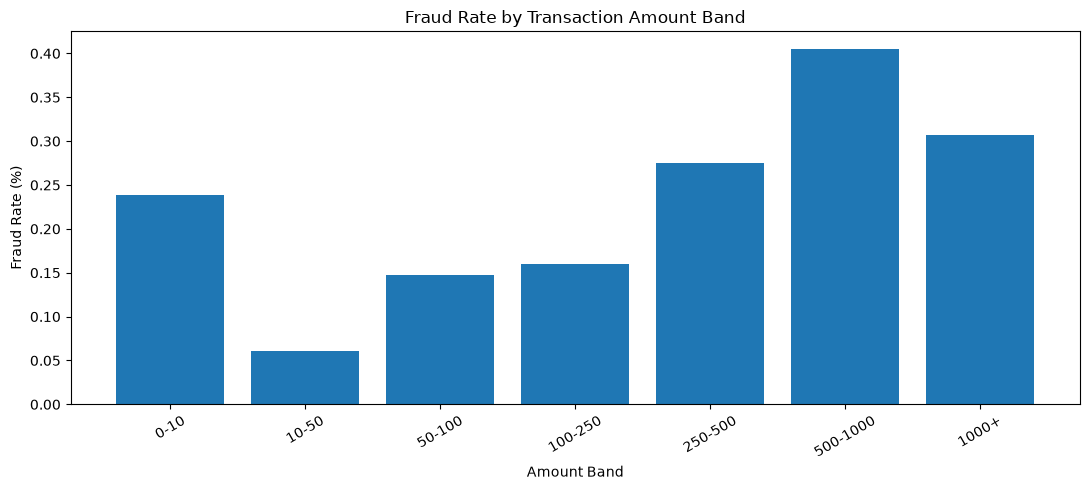

In [17]:
bins = [0, 10, 50, 100, 250, 500, 1000, np.inf]
labels = [
    "0-10", "10-50", "50-100", "100-250",
    "250-500", "500-1000", "1000+"
]

df["Amount_Band"] = pd.cut(
    df["Amount"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

amount_band = (
    df.groupby("Amount_Band", observed=False)
      .agg(
          Transactions=("Amount", "size"),
          Fraud_Count=("Class", "sum"),
          Total_Amount=("Amount", "sum")
      )
)

amount_band["Fraud_Rate_%"] = (
    amount_band["Fraud_Count"] / amount_band["Transactions"] * 100
)

print("\n========== AMOUNT BAND ANALYSIS ==========")
print(amount_band)

plt.figure(figsize=(11, 5))
plt.bar(amount_band.index.astype(str), amount_band["Fraud_Rate_%"])
plt.title("Fraud Rate by Transaction Amount Band")
plt.xlabel("Amount Band")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Correlation with Amount/Class

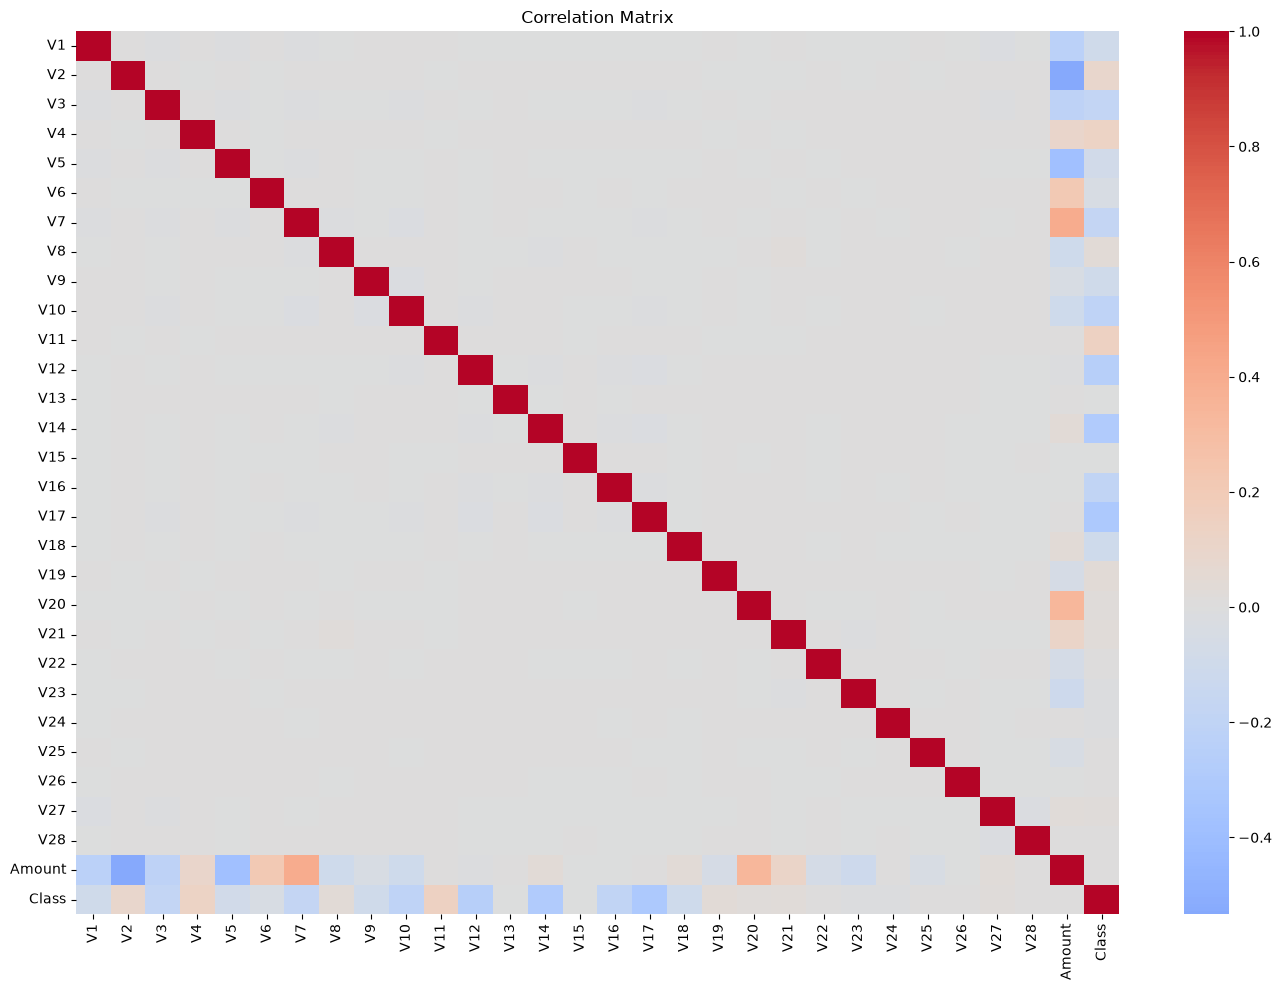


========== CORRELATION WITH FRAUD CLASS ==========
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64


In [18]:
corr = df[
    [c for c in df.columns if c.startswith("V")]
    + ["Amount", "Class"]
].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\n========== CORRELATION WITH FRAUD CLASS ==========")
print(
    corr["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
    .head(10)
)


 Simple business insights

In [19]:
peak_hour = time_summary["Transactions"].idxmax()
highest_fraud_hour = time_summary["Fraud_Rate_%"].idxmax()
highest_amount_band = amount_band["Fraud_Rate_%"].idxmax()

print("\n========== BUSINESS INSIGHTS ==========")
print(f"1. The dataset contains {total_transactions:,} transactions.")
print(f"2. Overall fraud rate is {fraud_rate:.3f}%.")
print(f"3. Highest transaction volume occurs around hour {peak_hour}:00.")
print(
    f"4. Highest observed fraud rate is in the "
    f"{highest_fraud_hour}:00 hour."
)
print(
    f"5. The amount band with the highest fraud rate is "
    f"{highest_amount_band}."
)
print(
    "6. Fraud and legitimate transactions should be evaluated using "
    "both transaction count and transaction value."
)



========== BUSINESS INSIGHTS ==========
1. The dataset contains 283,726 transactions.
2. Overall fraud rate is 0.167%.
3. Highest transaction volume occurs around hour 21:00.
4. Highest observed fraud rate is in the 2:00 hour.
5. The amount band with the highest fraud rate is 500-1000.
6. Fraud and legitimate transactions should be evaluated using both transaction count and transaction value.


Export analysis tables

In [20]:
amount_by_type.to_csv("amount_by_transaction_type.csv")
time_summary.to_csv("hourly_transaction_analysis.csv")
amount_band.to_csv("amount_band_analysis.csv")
top_20.to_csv("top_20_transactions.csv", index=False)
top_fraud.to_csv("top_20_fraud_transactions.csv", index=False)

print("\nAnalysis files exported successfully.")


Analysis files exported successfully.
